# Rock-Paper-Scissors Image Classifier - Training 

**Goal.** Train a small Convolutional Neural Network (CNN) from scratch to classify hand gestures into three classes: `paper`, `rock`, `scissors`.

**Who this notebook is for.** AI students learning CNNs end-to-end, and AI engineers who want a clean, reproducible reference for image-classification training with `tf.data` + Keras 3.

**What you will learn (concept-by-concept):**
1. How to load image folders into a `tf.data.Dataset` and split train / validation / test correctly.
2. How to build a fast input pipeline using `cache`, `shuffle`, `prefetch`.
3. Why and how data augmentation regularises a vision model.
4. The anatomy of a CNN - `Conv2D`, `MaxPool2D`, `Flatten`, `Dropout`, `Dense` - and what each layer is doing geometrically.
5. Loss functions for classification: `sparse_categorical_crossentropy` vs `categorical_crossentropy`.
6. Training hygiene: `EarlyStopping`, `restore_best_weights`, training curves, and a confusion matrix on the *real* test set.
7. Saving a Keras 3 model in the new `.keras` format for reuse in production / inference notebooks.

## 0. Environment and imports

We use **Keras 3** (the multi-backend Keras) on top of **TensorFlow**. Keras 3 also runs on JAX and PyTorch backends - the model code in this notebook is portable across them. We also import `numpy` for array work and `matplotlib` for plots.


In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

import keras
from keras import layers
import tensorflow as tf

print(f'TensorFlow : {tf.__version__}')
print(f'Keras : {keras.__version__}')
print(f'GPU avail : {bool(tf.config.list_physical_devices("GPU"))}')


2026-05-04 17:06:24.051983: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow : 2.16.2
Keras : 3.14.0
GPU avail : False


## 1. Configuration constants

Putting hyperparameters at the top makes experiments reproducible and easy to scan. A few notes:

- **`IMAGE_SIZE = (150, 150)`** - RPS images are originally 300×300. We downscale to 150×150 to roughly 4× the speed and reduce memory, with negligible accuracy loss for this task.
- **`BATCH_SIZE = 32`** - A common default. Larger batches -> smoother gradient estimates but more memory; smaller batches -> noisier gradients (which can act as a mild regulariser).
- **`SEED = 42`** - Used for the train/val split *and* for shuffling. Same seed -> same split every run, which is essential when comparing experiments.


In [ ]:
IMAGE_SIZE = (150, 150)
BATCH_SIZE = 32
SEED = 42
EPOCHS = 50                         
DATA_DIR = 'rps_dataset/train'      # train + validation source
TEST_DIR = 'rps_dataset/test'       # held-out test set

keras.utils.set_random_seed(SEED)   # seeds python, numpy, and the backend RNG

## 2. Loading images from disk

`keras.utils.image_dataset_from_directory` walks a folder structure like:

```
rps_dataset/train/
├── paper/      *.png
├── rock/       *.png
└── scissors/   *.png
```

and infers the **label from the folder name**. By default labels are integer-encoded in alphabetical order, so:

| folder    | label |
|-----------|-------|
| paper     | 0     |
| rock      | 1     |
| scissors  | 2     |

We pass `validation_split=0.2` and `subset="training" / "validation"` to carve out 20% of the directory for validation. The **same `seed` must be used for both calls** so the two subsets are disjoint.


In [ ]:
train_ds = keras.utils.image_dataset_from_directory(
    DATA_DIR,
    image_size = IMAGE_SIZE,
    batch_size = BATCH_SIZE,
    validation_split = 0.2,
    subset = 'training',
    seed = SEED,
)

val_ds = keras.utils.image_dataset_from_directory(
    DATA_DIR,
    image_size = IMAGE_SIZE,
    batch_size = BATCH_SIZE,
    validation_split = 0.2,
    subset = 'validation',
    seed = SEED,                # MUST match the training call
)

# A separate, pre-defined test set — never seen during training or model selection.
test_ds = keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size = IMAGE_SIZE,
    batch_size = BATCH_SIZE,
    shuffle = False,                  # keep order so confusion matrix labels line up
)

Found 2520 files belonging to 3 classes.
Using 2016 files for training.
Found 2520 files belonging to 3 classes.
Using 504 files for validation.
Found 372 files belonging to 3 classes.


### 2.1 Inspect the classes

We capture `class_names` *before* applying any `tf.data` transforms - once you `map`, `cache`, etc., the attribute is no longer attached to the dataset object.


In [ ]:
class_names = train_ds.class_names
num_classes = len(class_names)
print('Classes :', class_names)
print('Num :', num_classes)

Classes : ['paper', 'rock', 'scissors']
Num : 3


### 2.2 Visualise a few samples

Always look at your data before modelling - it catches label leaks, wrong directories, and weird preprocessing 90% of the time.


2026-05-04 17:10:05.102896: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


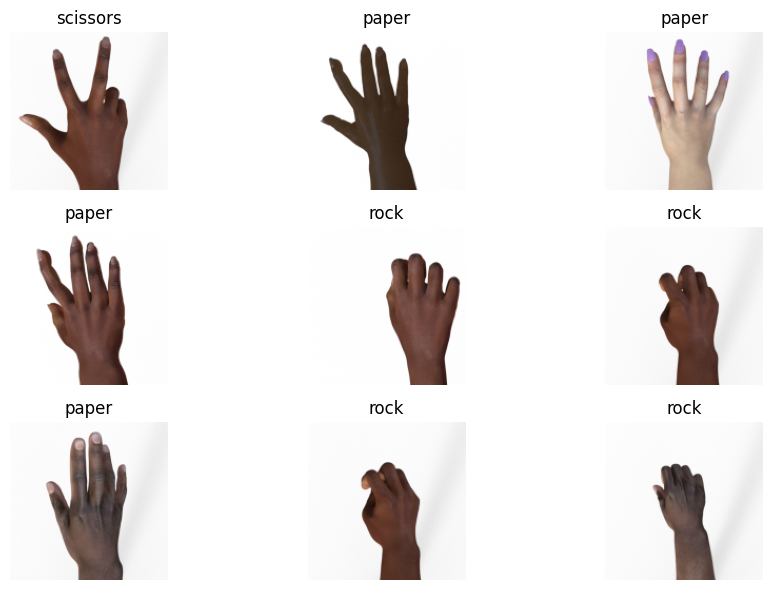

In [ ]:
plt.figure(figsize=(10, 6))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype('uint8'))
        plt.title(class_names[labels[i]])
        plt.axis('off')
plt.tight_layout()
plt.show()

## 3. Optimising the input pipeline with `tf.data`

On a non-trivial GPU, the model often *waits for data*. Three tiny optimisations remove that bottleneck:

| op              | what it does                                                                                  | why we want it                                  |
|-----------------|-----------------------------------------------------------------------------------------------|--------------------------------------------------|
| `cache()`       | Stores decoded images in RAM (or on disk) after the first epoch.                              | Skips JPEG/PNG decoding on every epoch.          |
| `shuffle(N)`    | Maintains a buffer of N samples and draws from it randomly.                                   | Breaks correlations between consecutive batches. |
| `prefetch(AT)`  | Loads the next batch on the CPU while the GPU is busy with the current one.                   | Overlaps I/O with compute.                       |

`tf.data.AUTOTUNE` lets TensorFlow pick the prefetch buffer size dynamically.

...

We also only `shuffle()` the training set - never validation or test, since shuffling them gives no benefit and breaks reproducibility of the confusion matrix.


In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000, seed=SEED).prefetch(AUTOTUNE)
val_ds = val_ds.cache().prefetch(AUTOTUNE)         # fixed (was train_ds in v1)
test_ds = test_ds.cache().prefetch(AUTOTUNE)       # ixed  (was train_ds in v1)

## 4. Data augmentation

We have ~2,000 training images - small for a CNN trained from scratch. **Data augmentation** synthesises new training examples on the fly by applying *label-preserving* random transforms. It is one of the cheapest and most effective forms of regularisation in computer vision.

Each augmentation layer behaves differently in train vs. inference mode:

| layer                       | training behaviour                                  | inference behaviour |
|-----------------------------|-----------------------------------------------------|---------------------|
| `RandomFlip("horizontal")` | 50% chance of mirroring left↔right                 | identity            |
| `RandomRotation(0.2)`       | rotate by ±0.2 × 360° = ±72° (uniform)              | identity            |
| `RandomZoom(0.2)`           | zoom in/out by up to 20%                            | identity            |

Because these layers are part of the model graph, augmentation runs on the **GPU** when available, and is *automatically disabled* when you call `model.predict` or `model.evaluate`. Putting them in the model (rather than in `tf.data.map`) is the modern Keras 3 idiom.

...

> **Choice of intensity.** ±72° is aggressive and is justified for RPS because hands are the same gesture at any rotation. For datasets where orientation matters (e.g. digits 6/9), use a much smaller rotation factor.


In [7]:
data_augmentation = keras.Sequential(
    [
        layers.RandomFlip('horizontal'),
        layers.RandomRotation(0.2),
        layers.RandomZoom(0.2),
    ],
    name='data_augmentation',
)

### 4.1 Visualise augmentation

Same image, nine random augmentations. Sanity-check that the gesture is still recognisable in every variant - if it isn't, your augmentations are too strong.


2026-05-04 17:12:41.508266: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


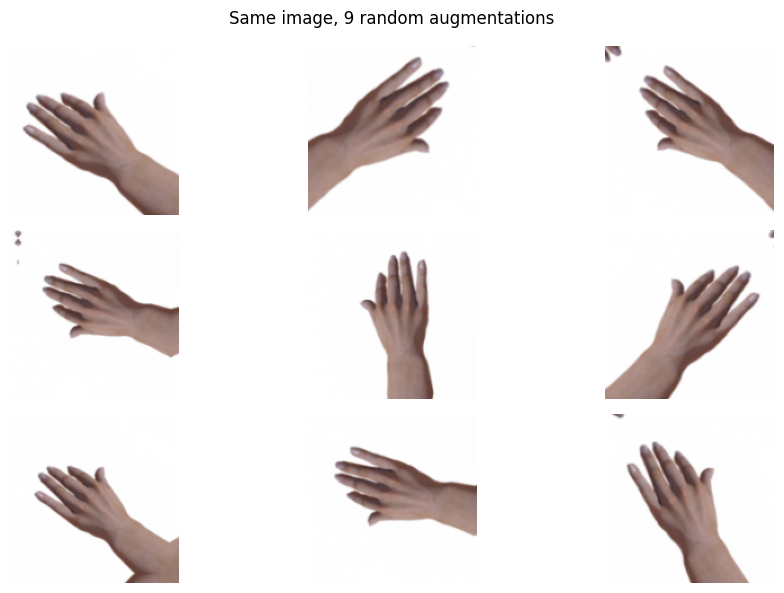

In [9]:
plt.figure(figsize=(10, 6))
for images, _ in train_ds.take(1):
    first = images[0:1]    # keep the leading batch dim
    for i in range(9):
        augmented = data_augmentation(first, training=True)
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(augmented[0].numpy().astype('uint8'))
        plt.axis('off')
plt.suptitle('Same image, 9 random augmentations')
plt.tight_layout()
plt.show()

## 5. Building the CNN

Our network follows the classic **VGG-style pattern**: a stack of `Conv -> ReLU -> MaxPool` blocks, where each block roughly doubles the number of feature maps and halves the spatial resolution. The intuition:

- Early layers learn low-level features (edges, gradients, simple textures). They need many spatial positions but few channels.
- Later layers learn high-level concepts (a fingertip shape, a fist contour). They benefit from many channels but few spatial positions.

**Layer-by-layer:**

| layer                              | output shape         | parameters | what it does                                                            |
|------------------------------------|----------------------|------------|-------------------------------------------------------------------------|
| `Input(150,150,3)`                 | (B, 150, 150, 3)     | 0          | enter image batch (B = batch size)                                      |
| `data_augmentation`                | (B, 150, 150, 3)     | 0          | random flips/rotations/zooms during training                            |
| `Rescaling(1./255)`                | (B, 150, 150, 3)     | 0          | maps pixel values from `[0, 255]` -> `[0, 1]` - keeps gradients sane     |
| `Conv2D(32, 3, same, relu)`        | (B, 150, 150, 32)    | ~896       | 32 learned 3×3 filters, each scans the whole image                      |
| `MaxPool2D()`                      | (B, 75, 75, 32)      | 0          | take the max in each 2×2 window -> halves spatial dims, adds invariance  |
| `Conv2D(64, 3, same, relu)`        | (B, 75, 75, 64)      | ~18 K      | richer features, more channels                                          |
| `MaxPool2D()`                      | (B, 37, 37, 64)      | 0          |                                                                         |
| `Conv2D(128, 3, same, relu)`       | (B, 37, 37, 128)     | ~74 K      |                                                                         |
| `MaxPool2D()`                      | (B, 18, 18, 128)     | 0          |                                                                         |
| `Conv2D(128, 3, same, relu)`       | (B, 18, 18, 128)     | ~148 K     |                                                                         |
| `MaxPool2D()`                      | (B, 9, 9, 128)       | 0          |                                                                         |
| `Flatten()`                        | (B, 10 368)          | 0          | flattens spatial+channel dims into a single vector                      |
| `Dropout(0.5)`                     | (B, 10 368)          | 0          | zeroes 50% of activations during training -> strong regulariser          |
| `Dense(128, relu)`                 | (B, 128)             | ~1.3 M     | fully-connected reasoning over the global feature vector                |
| `Dense(num_classes, softmax)`      | (B, 3)               | ~387       | per-class probabilities (sum to 1)                                      |

**Why `padding="same"`?** Without padding, a 3×3 conv shrinks spatial dimensions by 2 every layer. Padding with zeros keeps the spatial size constant inside a block, so we only downsample when *we* (`MaxPool`) say so.

**Why `Dropout` *before* the dense head?** The flatten produces ~10K activations - a notorious overfitting hotspot. Dropping 50% of them during training forces the dense layer to learn redundant features.

**Why `softmax` + `sparse_categorical_crossentropy`?** Softmax converts the 3 raw scores (logits) into probabilities. The *sparse* variant of cross-entropy expects integer labels (`0/1/2`), which is exactly what `image_dataset_from_directory` produces. Use the non-sparse variant only if your labels are one-hot vectors.


In [ ]:
model = keras.Sequential(
    [
        keras.Input(shape=(*IMAGE_SIZE, 3)),
        data_augmentation,
        layers.Rescaling(1.0 / 255),

        layers.Conv2D(32,  3, padding='same', activation='relu'),
        layers.MaxPool2D(),

        layers.Conv2D(64,  3, padding='same', activation='relu'),
        layers.MaxPool2D(),

        layers.Conv2D(128, 3, padding='same', activation='relu'),
        layers.MaxPool2D(),

        layers.Conv2D(128, 3, padding='same', activation='relu'),
        layers.MaxPool2D(),

        layers.Flatten(),
        layers.Dropout(0.5),
        layers.Dense(128, activation='relu'),
        layers.Dense(num_classes, activation='softmax'),
    ],
    name='rps_cnn',
)

model.summary()

Model: "rps_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 150, 150, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 37, 37, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 18, 18, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 9, 9, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 10368)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 10368)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,327,232 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,568,451 (5.98 MB)

 Trainable params: 1,568,451 (5.98 MB)

 Non-trainable params: 0 (0.00 B)

## 6. Compile

Compiling attaches an **optimizer**, a **loss function**, and **metrics** to the model.

- **Adam** - adaptive learning-rate optimiser, a sensible default for ~95% of vision tasks. Default learning rate is `1e-3`, which usually works for this scale of model.
- **`sparse_categorical_crossentropy`** - measures the negative log-likelihood the model assigns to the correct class. Lower is better.
- **`accuracy`** - the metric humans actually care about; reported alongside the loss.


In [11]:
model.compile(
    optimizer = keras.optimizers.Adam(learning_rate=1e-3),
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy'],
)

## 7. Train, with EarlyStopping + ModelCheckpoint

Two callbacks make training robust:

- **`EarlyStopping`** - monitors `val_loss` and stops training if it doesn't improve for `patience` epochs. With `restore_best_weights=True`, the model rolls back to the weights from the best epoch - so even if it overfits late, your final model is the one that generalised best.
- **`ModelCheckpoint`** - saves the best model to disk during training. Useful if your runtime crashes or you want to compare snapshots.

We set `EPOCHS=50` as an *upper bound*; in practice EarlyStopping will halt around epoch 15-25 for this problem.


In [12]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor = 'val_loss',
        patience = 5,
        restore_best_weights = True,
        verbose = 1,
    ),
    keras.callbacks.ModelCheckpoint(
        filepath = 'rps_cnn_best.keras',
        monitor = 'val_accuracy',
        save_best_only = True,
        verbose = 1,
    ),
]

history = model.fit(
    train_ds,
    validation_data = val_ds,
    epochs = EPOCHS,
    callbacks = callbacks,
)

Epoch 1/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 559ms/step - accuracy: 0.3317 - loss: 1.1482
Epoch 1: val_accuracy improved from None to 0.30556, saving model to rps_cnn_best.keras

Epoch 1: finished saving model to rps_cnn_best.keras
63/63 ━━━━━━━━━━━━━━━━━━━━ 40s 605ms/step - accuracy: 0.3482 - loss: 1.1104 - val_accuracy: 0.3056 - val_loss: 1.0749
Epoch 2/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 509ms/step - accuracy: 0.5153 - loss: 0.9653
Epoch 2: val_accuracy improved from 0.30556 to 0.64683, saving model to rps_cnn_best.keras

Epoch 2: finished saving model to rps_cnn_best.keras
63/63 ━━━━━━━━━━━━━━━━━━━━ 34s 540ms/step - accuracy: 0.5784 - loss: 0.8743 - val_accuracy: 0.6468 - val_loss: 0.7160
Epoch 3/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 501ms/step - accuracy: 0.7373 - loss: 0.6180
Epoch 3: val_accuracy improved from 0.64683 to 0.91865, saving model to rps_cnn_best.keras

Epoch 3: finished saving model to rps_cnn_best.keras
63/63 ━━━━━━━━━━━━━━━━━━━━ 34s 533ms/step - accuracy: 0.7708 - loss: 0.546

## 8. Diagnose: training curves

Reading curves is half of being a good ML engineer. The shape of the gap between `train` and `val` is more informative than any single number.

- **Healthy run.** Both curves rise (or fall, for loss) together; small steady gap.
- **Underfitting.** Both curves flat at low accuracy -> model too small / training too short.
- **Overfitting.** Train keeps improving, val plateaus or worsens -> reduce capacity, add regularisation, augment more, or get more data.


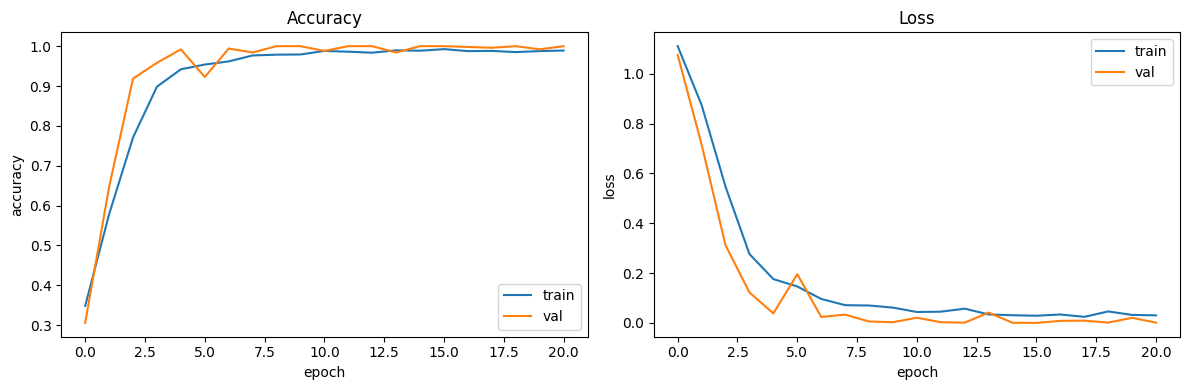

In [13]:
h = history.history
epochs_range = range(len(h['accuracy']))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs_range, h['accuracy'],     label='train')
axes[0].plot(epochs_range, h['val_accuracy'], label='val')
axes[0].set(title='Accuracy', xlabel='epoch', ylabel='accuracy')
axes[0].legend()

axes[1].plot(epochs_range, h['loss'],     label='train')
axes[1].plot(epochs_range, h['val_loss'], label='val')
axes[1].set(title='Loss', xlabel='epoch', ylabel='loss')
axes[1].legend()

plt.tight_layout()
plt.show()

## 9. Evaluate on the held-out test set

The test set was *never* used for early stopping, model selection, or augmentation tuning. Numbers reported here are your honest generalisation estimate.


In [14]:
test_loss, test_acc = model.evaluate(test_ds, verbose=1)
print(f'\nTest loss : {test_loss:.4f}')
print(f'Test accuracy : {test_acc:.4f}')

12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 135ms/step - accuracy: 0.9677 - loss: 0.0652

Test loss : 0.0652
Test accuracy : 0.9677


### 9.1 Confusion matrix

Accuracy alone hides which classes are confused with which. A confusion matrix turns one number into a 3×3 story.


2026-05-04 17:30:17.724204: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


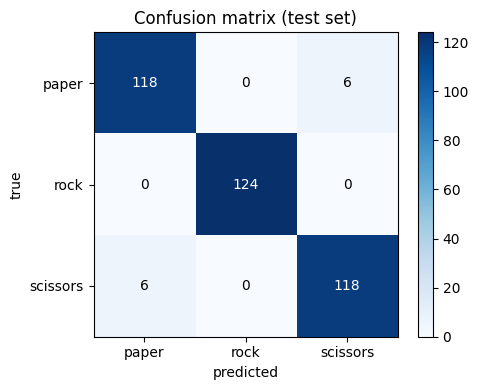

In [15]:
y_true = np.concatenate([y.numpy() for _, y in test_ds], axis=0)
y_pred = np.argmax(model.predict(test_ds, verbose=0), axis=1)

cm = tf.math.confusion_matrix(y_true, y_pred, num_classes=num_classes).numpy()

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks(range(num_classes), labels=class_names)
ax.set_yticks(range(num_classes), labels=class_names)
ax.set_xlabel('predicted'); ax.set_ylabel('true')
ax.set_title('Confusion matrix (test set)')
for i in range(num_classes):
    for j in range(num_classes):
        ax.text(j, i, cm[i, j], ha='center', va='center',
                color='white' if cm[i, j] > cm.max() / 2 else 'black')
plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.show()

### 9.2 Sample predictions on the test set

Showing predicted labels next to true labels surfaces the *kinds* of mistakes the model makes (e.g. 'fist confused with rock' vs. 'paper rotated 90° confused with scissors').


2026-05-04 17:30:35.795095: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


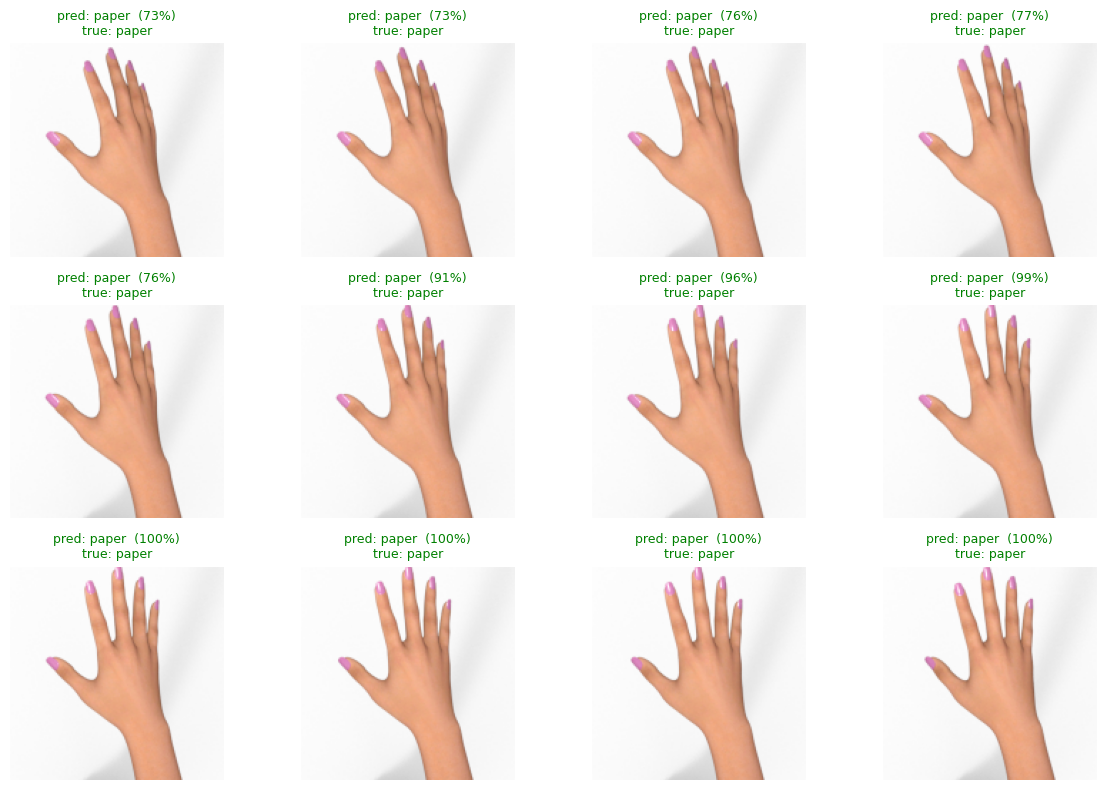

In [16]:
plt.figure(figsize=(12, 8))
for images, labels in test_ds.take(1):
    probs = model.predict(images, verbose=0)
    preds = np.argmax(probs, axis=1)
    for i in range(min(12, len(images))):
        ax = plt.subplot(3, 4, i + 1)
        plt.imshow(images[i].numpy().astype('uint8'))
        ok = preds[i] == labels[i].numpy()
        color = 'green' if ok else 'red'
        ax.set_title(f'pred: {class_names[preds[i]]}  ({100*probs[i].max():.0f}%)\n'
                     f'true: {class_names[labels[i]]}', color=color, fontsize=9)
        plt.axis('off')
plt.tight_layout()
plt.show()

## 10. Save the trained model

The new **`.keras`** format is a single zip-archive that bundles architecture, weights, and the optimiser state. Prefer it over the legacy `.h5` and `SavedModel` directory formats unless you have a specific reason not to.

Two saved files now exist:
- `rps_cnn_best.keras` - the best snapshot during training (saved by the checkpoint callback).
- `rps_cnn.keras` - saved here, *after* `restore_best_weights` from EarlyStopping has already rolled the model back to the best epoch.

Either is fine to use for inference. We save the second one so the inference notebook (`dl-v2-improved.ipynb`) can `keras.saving.load_model('rps_cnn.keras')` directly.


In [18]:
model.save('rps_cnn.keras')
print('Saved -> rps_cnn.keras')

Saved -> rps_cnn.keras


## 11. What to try next

If you want to push accuracy further, in order of expected payoff:

1. **Transfer learning.** Start from a pre-trained `MobileNetV2` or `EfficientNetB0`, freeze the backbone, and train only a new head. Usually gets to 99%+ on RPS in a few epochs.
2. **Learning-rate schedule.** Add `ReduceLROnPlateau` to drop the LR when `val_loss` stagnates.
3. **More augmentation.** `RandomContrast`, `RandomBrightness`, mild colour jitter.
4. **GlobalAveragePooling2D instead of Flatten.** Drops the dense layer's parameter count by ~80× and often generalises better.
5. **Per-class metrics.** Track precision, recall, and F1 per class - not just accuracy.
